# 08 — Nadzirano proširenje: predviđanje ostvarenog pada (predavanja 3-4)

Druga tehnika kolegija, na istim podacima. Za svaku dionicu i svaku kliznu
**testnu godinu** računamo ostvareni 12-mjesečni pad i označavamo ga `1`
(„visok pad”) ako je gori od **medijana presjeka** te godine,
inače `0`. Zatim predviđamo oznaku iz značajki poznatih na *početku*
godine (faktorske izloženosti prozora treniranja) i postavljamo KDD pitanje iz
`PROJECT_SPEC.md` §9:

> Poboljšava li dodavanje oznake **faktorskog klastera** (notebook 02) ili **GICS sektora**
> točnost izvan uzorka nad sirovim faktorskim betama?

Preslikavanje na kolegij:
- **Stabla odlučivanja** — *entropija / porast informacije* (C4.5) i *Gini* (CART),
  predavanje 3, uz `max_depth = 3` radi čitljivosti.
- **Ansambli** — *bagging* (slučajna šuma) i *boosting* (gradijentni boosting),
  predavanje 4.
- Evaluacija je **GroupKFold po testnoj godini** tako da nijedna kalendarska godina ne curi između
  preklopa treniranja i validacije.

Pomoćnici žive u `src/supervised.py`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")

from sklearn.tree import plot_tree, export_text
from src.backtest import generate_rolling_windows
from src.supervised import (build_drawdown_dataset, evaluate_feature_sets,
                            fit_interpretable_tree, feature_importances)
from src.utils import PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR, ensure_dirs, set_seed

ensure_dirs(); set_seed()
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

fe = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
fc = pd.read_csv(PROCESSED_DATA_DIR / "factor_clusters.csv")
meta = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")
mr = pd.read_csv(PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0)
windows = generate_rolling_windows()

data = build_drawdown_dataset(fe, mr, fc, meta, windows)
data.to_csv(TABLES_DIR / "08_drawdown_dataset.csv", index=False)
print(f"Skup podataka: {data.shape[0]} redaka (dionica, testna godina) kroz {data.test_year.nunique()} godina")
print(f"Ravnoteža ciljne varijable (udio visokog pada): {data.target.mean():.3f}")
data.head(3)


Skup podataka: 11762 redaka (dionica, testna godina) kroz 16 godina
Ravnoteža ciljne varijable (udio visokog pada): 0.500


,beta_mkt,beta_smb,beta_hml,beta_rmw,beta_cma,residual_vol,sector,factor_cluster,drawdown,test_year,ticker,target
0,1.379125,0.538637,-1.021563,-1.520225,1.775913,0.076538,Health Care,5,-0.256206,2010,A,1
1,2.085554,0.904369,-0.188863,1.116556,-0.637830,0.073703,Materials,7,-0.291851,2010,AA,1
2,0.850390,0.555747,-0.260110,0.458402,0.643152,0.089361,Industrials,5,-0.107401,2010,AAON,0


## 8.1 Unakrsno validirana točnost i ROC-AUC

Četiri modela × tri skupa značajki, GroupKFold po testnoj godini.


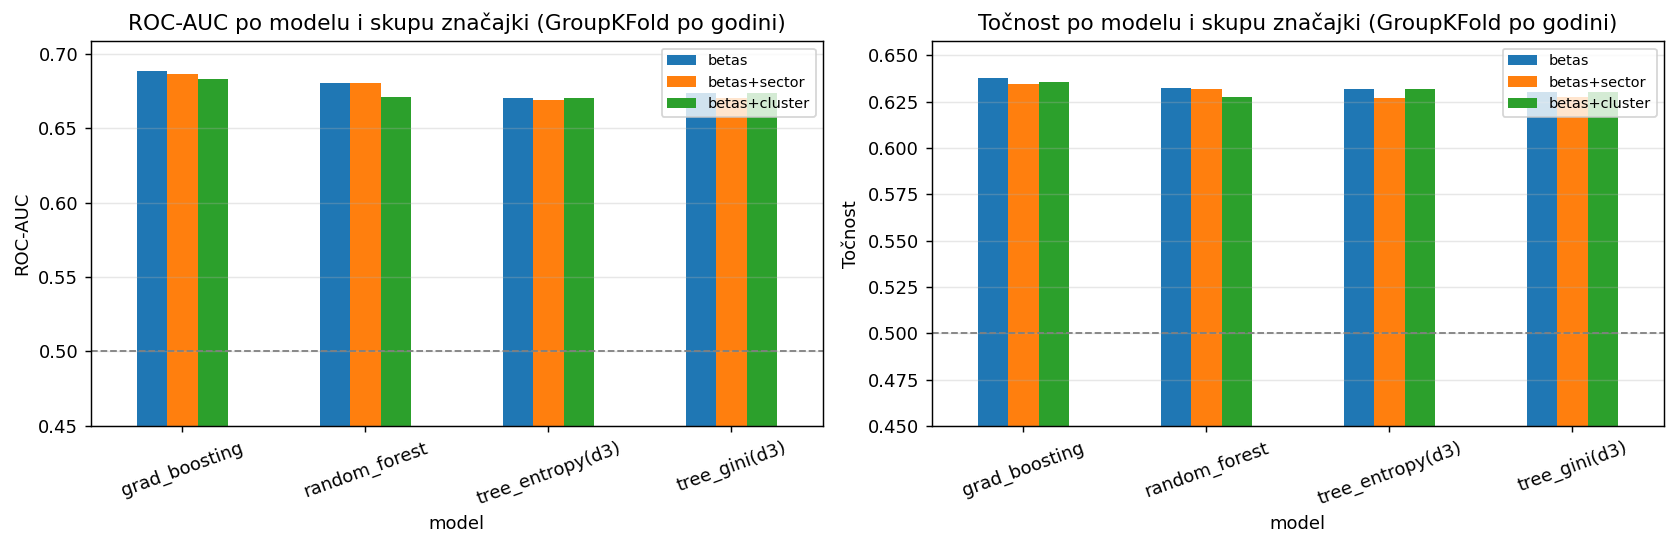

           model   feature_set  n_features  acc_mean  acc_std  auc_mean  auc_std
tree_entropy(d3)         betas           6    0.6317   0.0169    0.6705   0.0209
   tree_gini(d3)         betas           6    0.6300   0.0141    0.6738   0.0265
   random_forest         betas           6    0.6321   0.0169    0.6802   0.0175
   grad_boosting         betas           6    0.6375   0.0188    0.6882   0.0259
tree_entropy(d3)  betas+sector          17    0.6269   0.0094    0.6690   0.0195
   tree_gini(d3)  betas+sector          17    0.6273   0.0100    0.6705   0.0221
   random_forest  betas+sector          17    0.6316   0.0104    0.6806   0.0146
   grad_boosting  betas+sector          17    0.6343   0.0156    0.6862   0.0241
tree_entropy(d3) betas+cluster          13    0.6317   0.0169    0.6705   0.0209
   tree_gini(d3) betas+cluster          13    0.6300   0.0141    0.6738   0.0265
   random_forest betas+cluster          13    0.6273   0.0169    0.6709   0.0231
   grad_boosting betas+clust

In [2]:
res = evaluate_feature_sets(data)
res.to_csv(TABLES_DIR / "08_cv_results.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, metric, lab in [(axes[0], "auc_mean", "ROC-AUC"), (axes[1], "acc_mean", "Točnost")]:
    piv = res.pivot(index="model", columns="feature_set", values=metric)
    piv = piv[["betas", "betas+sector", "betas+cluster"]]
    piv.plot(kind="bar", ax=ax, rot=20)
    ax.axhline(0.5, color="grey", ls="--", lw=1)
    ax.set_title(f"{lab} po modelu i skupu značajki (GroupKFold po godini)")
    ax.set_ylabel(lab); ax.set_ylim(0.45, max(0.62, piv.values.max() + 0.02))
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "08_cv_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(res.round(4).to_string(index=False))


**Zaključak.** „Visok pad” sljedeće godine *umjereno* je predvidljiv iz
faktorskih izloženosti prozora treniranja: gradijentni boosting doseže **ROC-AUC ≈ 0.69,
točnost ≈ 0.64** (naspram linije slučaja od 0.5), uz stabla odlučivanja i slučajnu
šumu tik iza. Ključno, dodavanje GICS **sektora** ili oznake
**faktorskog klastera** **ne** poboljšava nad sirovih šest značajki
(AUC u biti nepromijenjen, ≈ 0.68–0.69): faktorske bete — a osobito
`residual_vol` — već nose signal, pa je oznaka klastera snažan
*deskriptivni* objekt, ali ne i dodatna *prediktivna* značajka. To što je signal
uglavnom idiosinkratski rizik (sljedeći §) u skladu je s projektovim
okvirom dijagnoze, a ne predviđanja prinosa.


## 8.2 Interpretabilno stablo (entropija, dubina 3)


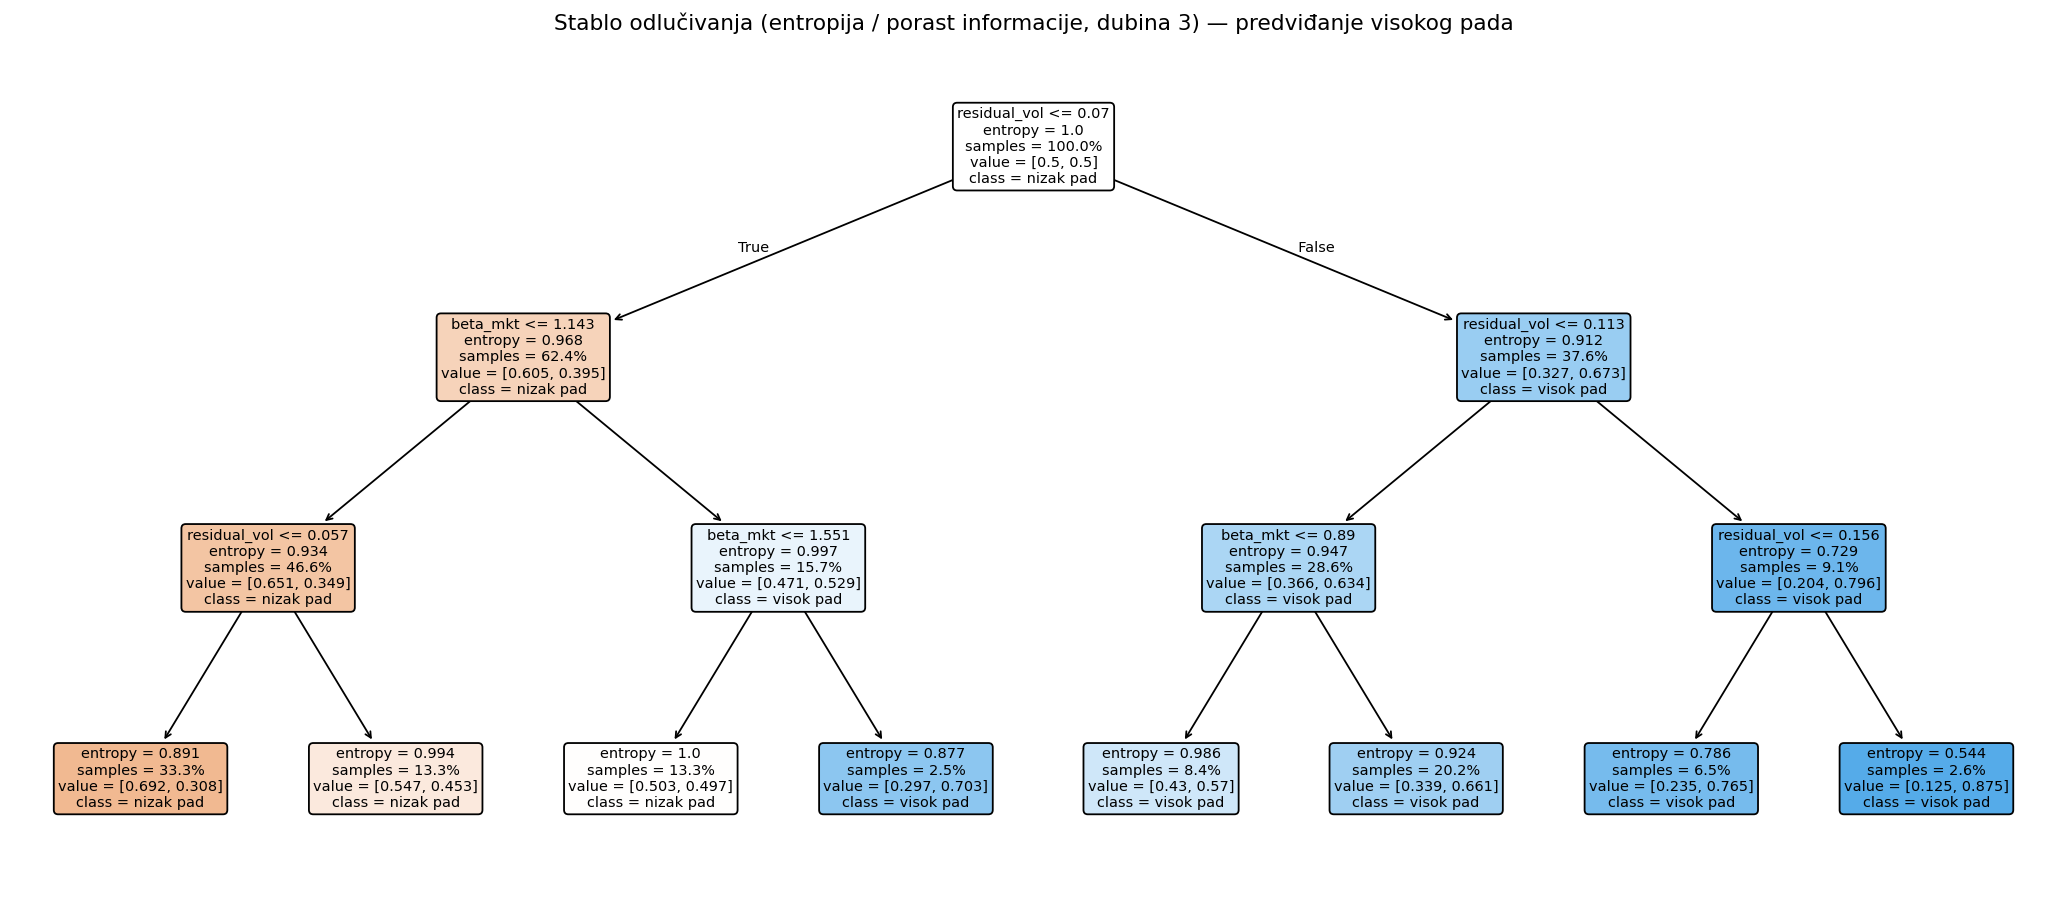

|--- residual_vol <= 0.07
|   |--- beta_mkt <= 1.14
|   |   |--- residual_vol <= 0.06
|   |   |   |--- class: 0
|   |   |--- residual_vol >  0.06
|   |   |   |--- class: 0
|   |--- beta_mkt >  1.14
|   |   |--- beta_mkt <= 1.55
|   |   |   |--- class: 0
|   |   |--- beta_mkt >  1.55
|   |   |   |--- class: 1
|--- residual_vol >  0.07
|   |--- residual_vol <= 0.11
|   |   |--- beta_mkt <= 0.89
|   |   |   |--- class: 1
|   |   |--- beta_mkt >  0.89
|   |   |   |--- class: 1
|   |--- residual_vol >  0.11
|   |   |--- residual_vol <= 0.16
|   |   |   |--- class: 1
|   |   |--- residual_vol >  0.16
|   |   |   |--- class: 1



In [3]:
tree, feat_names = fit_interpretable_tree(data, feature_set="betas+cluster",
                                          max_depth=3, criterion="entropy")
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(tree, feature_names=feat_names, class_names=["nizak pad", "visok pad"],
          filled=True, rounded=True, fontsize=8, ax=ax, impurity=True, proportion=True)
ax.set_title("Stablo odlučivanja (entropija / porast informacije, dubina 3) — predviđanje visokog pada")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "08_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print(export_text(tree, feature_names=feat_names, max_depth=3))


## 8.3 Koje značajke su bitne? (važnosti iz slučajne šume)


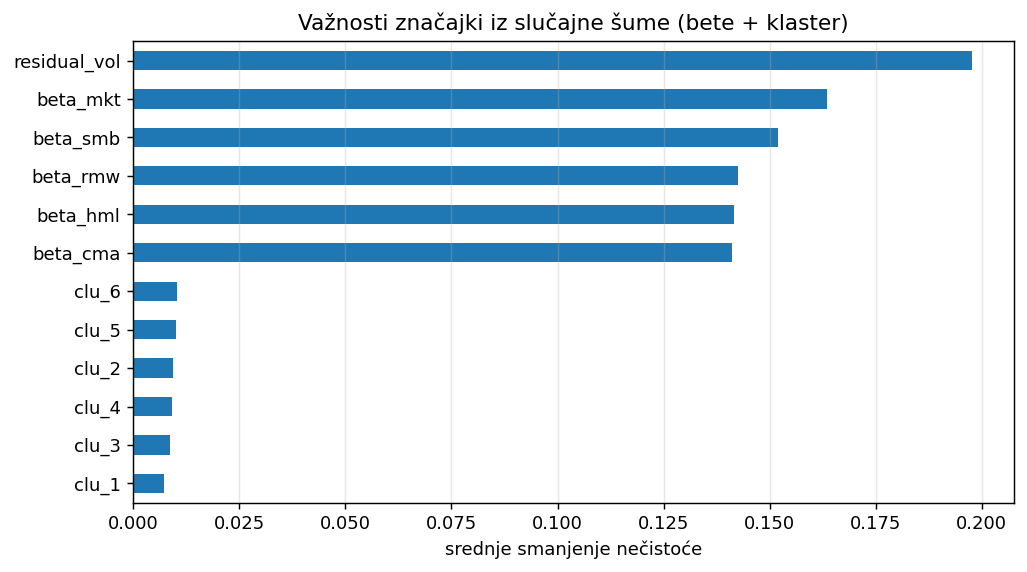

residual_vol    0.1977
beta_mkt        0.1635
beta_smb        0.1519
beta_rmw        0.1425
beta_hml        0.1415
beta_cma        0.1410
clu_6           0.0103
clu_5           0.0101
clu_2           0.0094
clu_4           0.0090
clu_3           0.0088
clu_1           0.0072


In [4]:
imp = feature_importances(data, feature_set="betas+cluster").head(12)
imp.to_csv(TABLES_DIR / "08_feature_importances.csv")
fig, ax = plt.subplots(figsize=(8, 4.5))
imp[::-1].plot(kind="barh", ax=ax, color="C0")
ax.set_title("Važnosti značajki iz slučajne šume (bete + klaster)")
ax.set_xlabel("srednje smanjenje nečistoće"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "08_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()
print(imp.round(4).to_string())


## 8.4 Zaključci (usklađenost s kolegijem)

| Tema kolegija | Predavanje | Korišteno ovdje |
|---|---|---|
| Stabla odlučivanja — entropija / porast informacije (C4.5) | 3 | `tree_entropy(d3)`, čitljivo stablo dubine 3 |
| Stabla odlučivanja — Gini indeks (CART) | 3 | `tree_gini(d3)` |
| Ansambli — bagging (slučajna šuma) | 4 | `random_forest`, važnosti |
| Ansambli — boosting | 4 | `grad_boosting` |
| Poštena evaluacija modela — grupirana CV | 2/4 | GroupKFold po testnoj godini |

**Rezultat.** Ostvareni pad umjereno je predvidljiv u presjeku iz
faktorskih izloženosti (gradijentni boosting AUC ≈ 0.69), a važnosti pokazuju da signalom
dominira `residual_vol` (idiosinkratski rizik) i tržišna beta — a ne
stilski faktori. Oznaka faktorskog klastera — izvrstan *deskriptivni* sažetak
univerzuma — ne dodaje **nikakvu** materijalnu *prediktivnu* moć nad betama iz kojih je
izgrađena (AUC ≈ 0.68 s njom i bez nje). Proširenje demonstrira
nadzirani + ansamblski alat (stabla entropija/Gini, bagging, boosting) i pokazuje,
pošteno, da deskriptivna struktura klastera ne služi ujedno kao prediktivna
značajka.
